# 1. Data Acquisition
Tahap ini bertujuan untuk mengambil data film dari sumber eksternal menggunakan teknik **API (Application Programming Interface)**.
* **Sumber Data:** The Movie Database (TMDB) API.
* **Metode:** Mengambil data film terpopuler (*Discover Movie*) sebanyak 50 halaman (target ±1000 data).
* **Atribut yang diambil:** ID, Judul, Tanggal Rilis, Popularitas, Vote Average, Vote Count, dan Genre.

KONFIGURASI

In [ ]:
import requests
import pandas as pd
import time
# --- KONFIGURASI API ---
# API Key dimasukkan di sini
API_KEY = 'c11d133628e5b8875a0b59bdb29ebdaf'
BASE_URL = "https://api.themoviedb.org/3"
TOTAL_PAGES = 50   # Target 50 halaman x 20 film = 1000 data

def get_movie_data():
    """
    Fungsi untuk melakukan crawling data dari TMDB API.
    Mengembalikan DataFrame berisi data film.
    """
    movies = []
    print(f"Memulai koneksi ke TMDB API... Target: {TOTAL_PAGES} halaman.")

    # 1. Ambil Mapping Genre (Mengubah ID angka menjadi Teks Genre)
    genre_url = f"{BASE_URL}/genre/movie/list?api_key={API_KEY}&language=en-US"
    try:
        genre_response = requests.get(genre_url).json()
        if 'genres' in genre_response:
            genre_map = {g['id']: g['name'] for g in genre_response['genres']}
        else:
            print("Gagal mengambil referensi genre.")
            return pd.DataFrame()
    except Exception as e:
        print(f"Error koneksi genre: {e}")
        return pd.DataFrame()

    # 2. Loop Iterasi Halaman (Pagination)
    for page in range(1, TOTAL_PAGES + 1):
        url = f"{BASE_URL}/discover/movie?api_key={API_KEY}&sort_by=popularity.desc&page={page}"

        try:
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                results = data['results']

                for item in results:
                    # Mengambil genre utama saja
                    g_id = item['genre_ids'][0] if item['genre_ids'] else None
                    genre_name = genre_map.get(g_id, 'Unknown')

                    movies.append({
                        'id': item['id'],
                        'title': item['title'],
                        'release_date': item.get('release_date', None),
                        'popularity': item['popularity'],
                        'vote_average': item['vote_average'],
                        'vote_count': item['vote_count'],
                        'original_language': item['original_language'],
                        'genre': genre_name
                    })

                # Log progress sederhana
                if page % 10 == 0:
                    print(f"Progress: {page}/{TOTAL_PAGES} halaman berhasil diambil.")
            else:
                print(f"Gagal di halaman {page}. Status: {response.status_code}")

            # Rate Limiting: Jeda agar tidak dianggap spam oleh server
            time.sleep(0.1)

        except Exception as e:
            print(f"Error pada halaman {page}: {e}")
            continue

    return pd.DataFrame(movies)

In [ ]:
# Eksekusi Pengambilan Data
print("Sedang mengambil data...")
df_movies = get_movie_data()

# Cek hasil dan Simpan
if not df_movies.empty:
    print("\n--- DATA ACQUISITION SUCCESS ---")
    print(f"Total data berhasil diambil: {len(df_movies)} baris.")

    # Menampilkan 5 data teratas
    display(df_movies.head())

    # menyimpan ke CSV untuk digunakan di tahap selanjutnya
    df_movies.to_csv('dataset_film_tmdb.csv', index=False)
    print("File tersimpan: 'dataset_film_tmdb.csv'")
else:
    print("Data kosong. Silakan cek API Key atau koneksi internet.")

Sedang mengambil data...
Memulai koneksi ke TMDB API... Target: 50 halaman.
Progress: 10/50 halaman berhasil diambil.
Progress: 20/50 halaman berhasil diambil.
Progress: 30/50 halaman berhasil diambil.
Progress: 40/50 halaman berhasil diambil.
Progress: 50/50 halaman berhasil diambil.

--- DATA ACQUISITION SUCCESS ---
Total data berhasil diambil: 1000 baris.


,id,title,release_date,popularity,vote_average,vote_count,original_language,genre
0,83533,Avatar: Fire and Ash,2025-12-17,544.1465,7.400,593,en,Science Fiction
1,982843,The Great Flood,2025-09-18,478.4638,6.068,222,ko,Science Fiction
2,425274,Now You See Me: Now You Don't,2025-11-12,324.1008,6.495,615,en,Thriller
3,1084242,Zootopia 2,2025-11-26,322.1041,7.657,722,en,Animation
4,1223601,Sisu: Road to Revenge,2025-10-21,265.0704,7.513,271,fi,Action


File tersimpan: 'dataset_film_tmdb.csv'


## 2. Data Preprocessing & Exploratory Data Analysis (EDA)
Sebelum dilakukan pemodelan, data mentah dari API perlu dibersihkan dan dipahami karakteristiknya.

**Langkah Preprocessing:**
1.  **Cek Konsistensi:** Memastikan tipe data benar.
2.  **Filtering:** Menghapus film dengan jumlah *vote* yang terlalu sedikit. Film dengan hanya 1-2 vote seringkali memiliki rating bias (misal 10/10 atau 0/10), sehingga dapat merusak pola klaster.
3.  **Handling Missing Values:** Menghapus data yang tidak lengkap.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv('dataset_film_tmdb.csv')

print(f"Jumlah data awal: {len(df)} baris")

# 2. Data Cleaning
# Hapus data duplikat
df_clean = df.drop_duplicates(subset=['id'])

# Hapus baris yang nilai 'vote_average' atau 'popularity' kosong
df_clean = df_clean.dropna(subset=['vote_average', 'popularity', 'title'])

# 3. FILTERING
#  film yang direview oleh minimal 50 orang
MIN_VOTES = 50
df_clean = df_clean[df_clean['vote_count'] >= MIN_VOTES]

# Reset index
df_clean.reset_index(drop=True, inplace=True)

print(f"Jumlah data setelah cleaning: {len(df_clean)} baris")
print("\n--- Sampel Data Bersih ---")
display(df_clean.head())

Jumlah data awal: 1000 baris
Jumlah data setelah cleaning: 794 baris

--- Sampel Data Bersih ---


,id,title,release_date,popularity,vote_average,vote_count,original_language,genre
0,83533,Avatar: Fire and Ash,2025-12-17,544.1465,7.400,593,en,Science Fiction
1,982843,The Great Flood,2025-09-18,478.4638,6.068,222,ko,Science Fiction
2,425274,Now You See Me: Now You Don't,2025-11-12,324.1008,6.495,615,en,Thriller
3,1084242,Zootopia 2,2025-11-26,322.1041,7.657,722,en,Animation
4,1223601,Sisu: Road to Revenge,2025-10-21,265.0704,7.513,271,fi,Action


### 2.1. Visualisasi Sebaran Data (EDA)
Kita akan melihat distribusi data menggunakan Histogram dan Scatter Plot untuk menjawab pertanyaan:
* Bagaimana sebaran rating film di pasaran?
* Apakah film populer selalu memiliki rating tinggi?

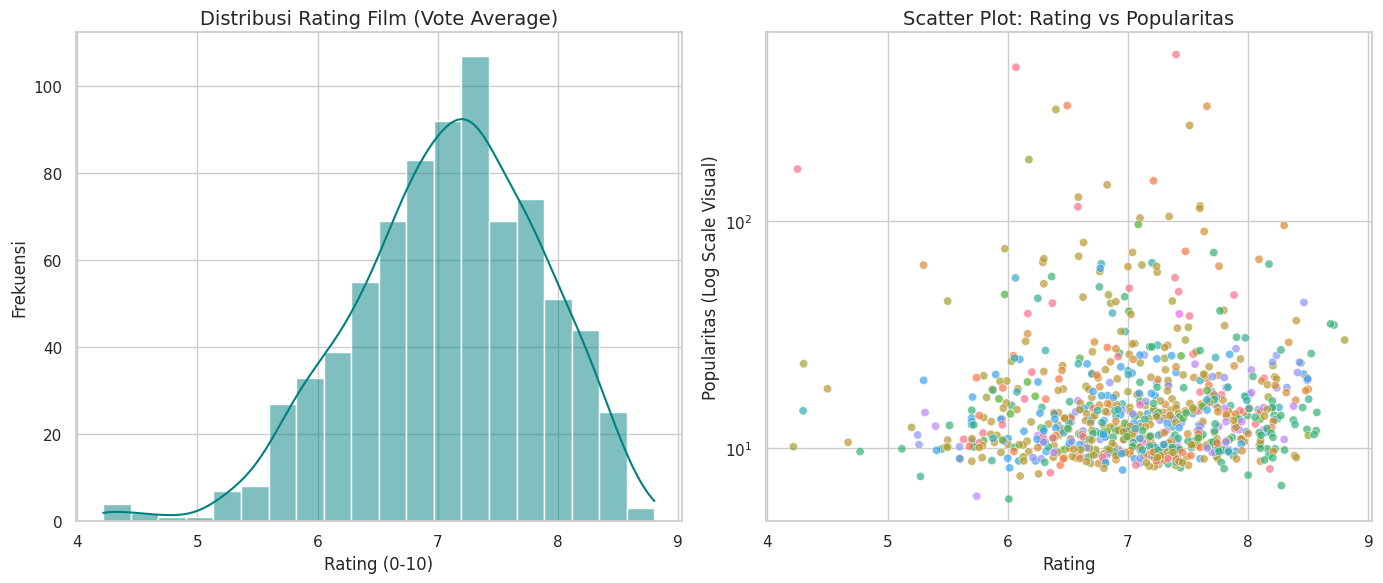

In [ ]:
# Set style visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Visualisasi 1: Distribusi Rating (Vote Average)
plt.subplot(1, 2, 1)
sns.histplot(df_clean['vote_average'], kde=True, color='teal', bins=20)
plt.title('Distribusi Rating Film (Vote Average)', fontsize=14)
plt.xlabel('Rating (0-10)')
plt.ylabel('Frekuensi')

# Visualisasi 2: Hubungan Popularitas vs Rating
plt.subplot(1, 2, 2)
# Menggunakan log scale untuk popularity
sns.scatterplot(data=df_clean, x='vote_average', y='popularity', hue='genre', alpha=0.7, legend=False)
plt.title('Scatter Plot: Rating vs Popularitas', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Popularitas (Log Scale Visual)')
plt.yscale('log') # Agar data yang menumpuk di bawah terlihat jelas

plt.tight_layout()
plt.show()


**Analisis Insight Awal:**
Berdasarkan visualisasi di atas

1.  **Distribusi Normal (Histogram):**
    Grafik menunjukkan dengan puncak di sekitar rating 7.0 - 7.5. Ini menunjukkan bahwa dataset didominasi oleh film-film dengan kualitas "Baik/Layak Tonton". Data tidak condong (skewed) ekstrem ke kiri atau kanan, sehingga aman untuk pemodelan statistik.

2.  **Pola Sebaran Acak (Scatter Plot):**
    Grafik memperlihatkan titik-titik yang menyebar dan tidak membentuk garis lurus diagonal. Artinya, **tidak ada korelasi linear yang kuat antara Popularitas dan Rating**.
    * Film dengan popularitas tinggi (posisi atas) belum tentu ratingnya 9 atau 10.
    * Film dengan rating tinggi (posisi kanan) banyak juga yang popularitasnya rendah.

**Kesimpulan:**
Karena data menyebar dan tidak memiliki pola linear, maka teknik **Clustering (K-Means)** adalah metode yang tepat untuk menemukan kelompok tersembunyi di dalam data ini.

## 3. Penerapan Data Mining: Clustering (K-Means)
Pada tahap ini, kita akan mengelompokkan film menggunakan algoritma **K-Means**.
Sebelum pemodelan, dilakukan proses:
1.  **Feature Selection:** Memilih atribut `popularity` dan `vote_average`.
2.  **Scaling:** Mengubah skala data menggunakan `StandardScaler` agar rentang nilai popularitas (ribuan) tidak mendominasi rating (satuan).
3.  **Elbow Method:** Mencari jumlah klaster (K) yang paling optimal.

Contoh 5 data setelah discaling:
[[14.20181862  0.41165229]
 [12.4187272  -1.30234955]
 [ 8.2282274  -0.75289101]
 [ 8.17402289  0.74235685]
 [ 6.62572628  0.55705935]]


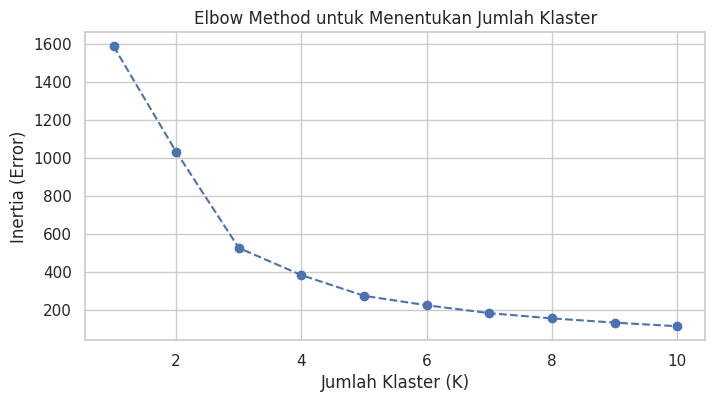

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
# Kita ambil dua fitur utama untuk diklaster
X = df_clean[['popularity', 'vote_average']]

# 2. Scaling (Standarisasi Data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cek hasil scaling (harus di sekitar angka -2 sampai 2)
print("Contoh 5 data setelah discaling:")
print(X_scaled[:5])

# 3. Mencari K Optimal dengan Elbow Method
inertia = []
range_k = range(1, 11) # Kita coba klaster 1 sampai 10

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow
plt.figure(figsize=(8, 4))
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.title('Elbow Method untuk Menentukan Jumlah Klaster')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia (Error)')
plt.grid(True)
plt.show()

### 3.1. Eksekusi K-Means Clustering
Berdasarkan hasil Elbow Method di atas, terlihat bahwa patahan siku (elbow) yang paling tajam berada di titik **K = 3**.
Berikut adalah tahapan pemodelan:
1.  Melatih model K-Means dengan 3 klaster.
2.  Menyimpan label hasil klaster (0, 1, atau 2) ke dalam dataset.
3.  Memvisualisasikan hasil pembagian kelompok film.

In [ ]:
# 1. Konfigurasi Model dengan K=3 (Sesuai hasil Elbow)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Eksekusi Clustering
# Kita fit ke data X_scaled, lalu hasilnya (label) kita simpan di DataFrame asli
df_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

# 3. Cek Distribusi Hasil Klaster
print("Jumlah film di setiap klaster:")
print(df_clean['cluster'].value_counts())

# Lihat data yang sudah punya label 'cluster'
print("\nContoh Data Hasil Labeling")
display(df_clean.head())

Jumlah film di setiap klaster:
cluster
0    456
1    332
2      6
Name: count, dtype: int64

Contoh Data Hasil Labeling


,id,title,release_date,popularity,vote_average,vote_count,original_language,genre,cluster
0,83533,Avatar: Fire and Ash,2025-12-17,544.1465,7.400,593,en,Science Fiction,2
1,982843,The Great Flood,2025-09-18,478.4638,6.068,222,ko,Science Fiction,2
2,425274,Now You See Me: Now You Don't,2025-11-12,324.1008,6.495,615,en,Thriller,2
3,1084242,Zootopia 2,2025-11-26,322.1041,7.657,722,en,Animation,2
4,1223601,Sisu: Road to Revenge,2025-10-21,265.0704,7.513,271,fi,Action,2


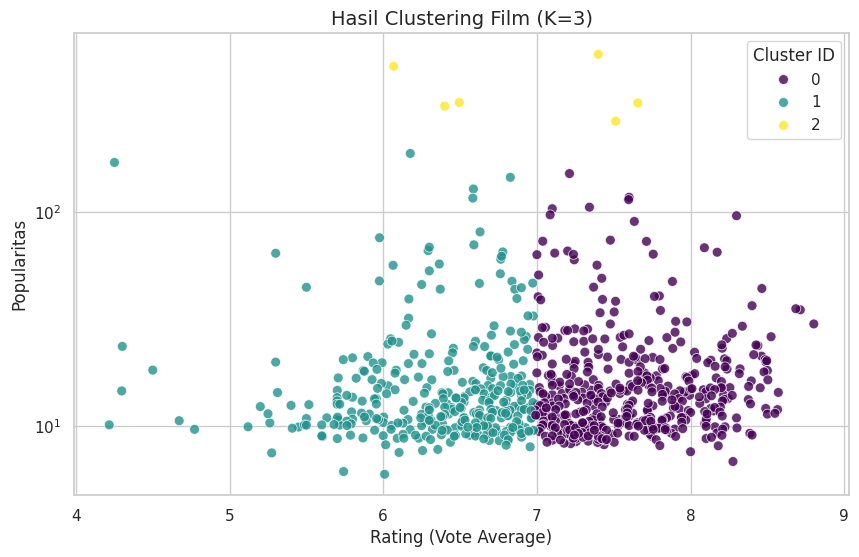

In [ ]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))

# Scatter plot dengan warna berbeda tiap klaster
# hue='cluster' artinya warna titik ditentukan oleh nomor klasternya
sns.scatterplot(
    data=df_clean,
    x='vote_average',
    y='popularity',
    hue='cluster',
    palette='viridis',
    s=50,
    alpha=0.8
)

# Visual Grafik
plt.title('Hasil Segmentasi Film (K=3)', fontsize=14)
plt.xlabel('Rating (Vote Average)')
plt.ylabel('Popularitas (Log Scale)')
plt.yscale('log')
plt.legend(title='Cluster Label')
plt.grid(True, alpha=0.3)
plt.show()

### 3.2. Interpretasi Profil Klaster
Berdasarkan visualisasi Scatter Plot di atas, terbentuk 3 kelompok film dengan karakteristik unik:

1.  **Cluster 2 (High Popularity - "Blockbuster"):**
    * Ditandai dengan titik berwarna **Kuning**.
    * **Ciri:** Memiliki popularitas ekstrem (Outliers).
    * **Insight:** Kelompok ini berisi film-film yang sedang *trending* atau *hype* besar-besaran. Kualitas ceritanya (rating) bervariasi, namun eksposur medianya sangat tinggi.

2.  **Cluster 0 (High Rating, Low Popularity - "Underrated"):**
    * Ditandai dengan titik berwarna **Ungu**.
    * **Ciri:** Rating rata-rata tinggi (> 7.0) namun popularitas standar.
    * **Insight:** Ini adalah film-film yang kualitasnya diakui sangat baik oleh penonton, meskipun popularitas nya kurang.

3.  **Cluster 1 (Low Rating - "Mediocre"):**
    * Ditandai dengan titik berwarna **Hijau tosca**.
    * **Ciri:** Rating cenderung rendah (< 7.0) dan popularitas rendah.
    * **Insight:** Film-film dengan performa rata-rata atau kurang memuaskan penonton.

## 4. Evaluasi Model
Untuk mengukur seberapa baik kualitas pengelompokan yang dilakukan oleh algoritma K-Means, kita menggunakan metrik **Silhouette Score**.
* Nilai mendekati **+1**: Klaster terpisah dengan sangat baik (Sempurna).
* Nilai sekitar **0**: Klaster tumpang tindih.
* Nilai negatif: Salah pengelompokan.

In [ ]:
from sklearn.metrics import silhouette_score

# Hitung Silhouette Score
score = silhouette_score(X_scaled, df_clean['cluster'])

print(f"Silhouette Score: {score:.4f}")

# Interpretasi Otomatis
if score > 0.5:
    print("Kualitas Klaster: SANGAT BAIK")
elif score > 0.2:
    print("Kualitas Klaster: CUKUP BAIK ")
else:
    print("Kualitas Klaster: BURUK")

Silhouette Score: 0.4862
Kualitas Klaster: CUKUP BAIK 


In [ ]:
# Simpan hasil akhir ke CSV
df_clean.to_csv('hasil_clustering_film_final.csv', index=False)

print("File 'hasil_clustering_film_final.csv' berhasil disimpan!")


File 'hasil_clustering_film_final.csv' berhasil disimpan!
